In [3]:
import json
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython import display
from nltk.tokenize import WordPunctTokenizer
from sklearn import naive_bayes
from sklearn.base import BaseEstimator
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from torch import nn
from torch.nn import functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau, StepLR

%matplotlib inline


out_dict = dict()
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

In [4]:
df = pd.read_csv(
    "https://github.com/clairett/pytorch-sentiment-classification/raw/master/data/SST2/train.tsv",
    delimiter="\t",
    header=None,
)
texts_train = df[0].values[:5000]
y_train = df[1].values[:5000]
texts_test = df[0].values[5000:]
y_test = df[1].values[5000:]


tokenizer = WordPunctTokenizer()
preprocess = lambda text: " ".join(tokenizer.tokenize(text.lower()))

text = 'How to be a grown-up at work: replace "I don\'t want to do that" with "Ok, great!".'
print("before:", text)
print("after:", preprocess(text))

texts_train = [preprocess(text) for text in texts_train]
texts_test = [preprocess(text) for text in texts_test]

assert (
    texts_train[5]
    == "campanella gets the tone just right funny in the middle of sad in the middle of hopeful"
)
assert texts_test[74] == "poetry in motion captured on film"
assert len(texts_test) == len(y_test)

before: How to be a grown-up at work: replace "I don't want to do that" with "Ok, great!".
after: how to be a grown - up at work : replace " i don ' t want to do that " with " ok , great !".


In [5]:
def plot_train_process(
    train_loss, val_loss, train_accuracy, val_accuracy, title_suffix=""
):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].set_title(" ".join(["Loss", title_suffix]))
    axes[0].plot(train_loss, label="train")
    axes[0].plot(val_loss, label="validation")
    axes[0].legend()

    axes[1].set_title(" ".join(["Validation accuracy", title_suffix]))
    axes[1].plot(train_accuracy, label="train")
    axes[1].plot(val_accuracy, label="validation")
    axes[1].legend()
    plt.show()


def visualize_and_save_results(
    model, model_name, X_train, X_test, y_train, y_test, out_dict
):
    for data_name, X, y, model_ in [
        ("train", X_train, y_train, model),
        ("test", X_test, y_test, model),
    ]:
        if isinstance(model_, BaseEstimator):
            proba = model_.predict_proba(X)[:, 1]
        elif isinstance(model_, nn.Module):
            with torch.no_grad():
                logits = model_(X)
                proba = F.softmax(logits, dim=1).cpu().numpy()[:, 1]
        else:
            raise ValueError("Unrecognized model type")

        auc = roc_auc_score(y, proba)

        out_dict[f"{model_name}_{data_name}"] = auc
        plt.plot(*roc_curve(y, proba)[:2], label="{} AUC={:.4f}".format(data_name, auc))

    plt.plot([0, 1], [0, 1], "--", color="black")
    plt.legend(fontsize="large")
    plt.title(model_name)
    plt.grid()
    return out_dict


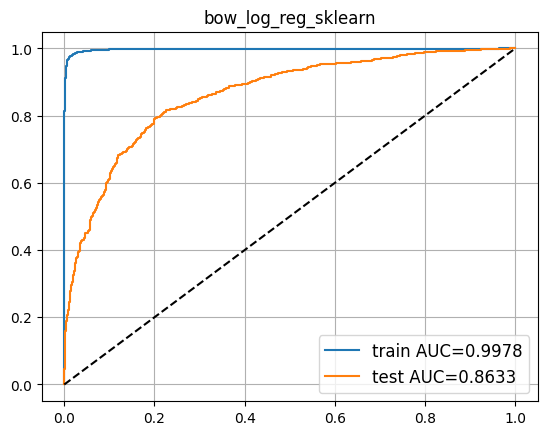

In [6]:
k = min(10000, len(set(" ".join(texts_train).split())))

counts = Counter(" ".join(texts_train).split())
bow_vocabulary = [key for key, val in counts.most_common(k)]

def text_to_bow(text):
    """convert text string to an array of token counts. Use bow_vocabulary."""
    sent_vec = np.zeros(len(bow_vocabulary), dtype=np.float32)
    c = Counter(text.split())
    for i, token in enumerate(bow_vocabulary):
        if token in c:
            sent_vec[i] = c[token]
    return sent_vec

X_train_bow = np.stack(list(map(text_to_bow, texts_train)))
X_test_bow = np.stack(list(map(text_to_bow, texts_test)))

k_max = len(set(" ".join(texts_train).split()))
assert X_train_bow.shape == (len(texts_train), min(k, k_max))
assert X_test_bow.shape == (len(texts_test), min(k, k_max))
assert np.all(
    X_train_bow[5:10].sum(-1) == np.array([len(s.split()) for s in texts_train[5:10]])
)
assert len(bow_vocabulary) <= min(k, k_max)
assert X_train_bow[65, bow_vocabulary.index("!")] == texts_train[65].split().count("!")

bow_model = LogisticRegression(max_iter=1500).fit(X_train_bow, y_train)

out_dict = visualize_and_save_results(
    bow_model, "bow_log_reg_sklearn", X_train_bow, X_test_bow, y_train, y_test, out_dict
)

In [7]:
class LogisticRegressionModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 2)
        
    def forward(self, x):
        return self.linear(x)

model = LogisticRegressionModel(X_train_bow.shape[1]).to(device)

loss_function = nn.CrossEntropyLoss()
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

X_train_bow_torch = torch.tensor(X_train_bow, dtype=torch.float32, device=device)
X_test_bow_torch = torch.tensor(X_test_bow, dtype=torch.float32, device=device)
y_train_torch = torch.tensor(y_train, dtype=torch.long, device=device)
y_test_torch = torch.tensor(y_test, dtype=torch.long, device=device)

/home/alex/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


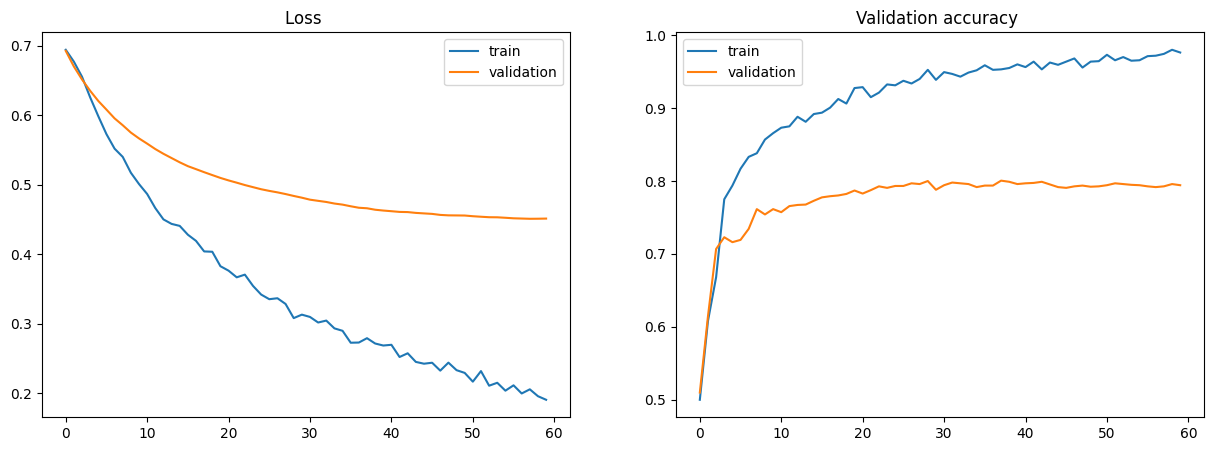

In [8]:
def train_model(
    model,
    opt,
    X_train_torch,
    y_train_torch,
    X_val_torch,
    y_val_torch,
    n_iterations=500,
    batch_size=32,
    show_plots=True,
    eval_every=50
):
    train_loss_history = []
    train_acc_history = []
    val_loss_history = []
    val_acc_history = []

    local_train_loss_history = []
    local_train_acc_history = []
    for i in range(n_iterations):

        ix = np.random.randint(0, len(X_train_torch), batch_size)
        x_batch = X_train_torch[ix]
        y_batch = y_train_torch[ix]

        y_predicted = model(x_batch)
        
        loss = loss_function(y_predicted, y_batch)

        loss.backward()

        opt.step()

        opt.zero_grad()

        local_train_loss_history.append(loss.item())
        local_train_acc_history.append(
            accuracy_score(
                y_batch.detach().cpu().numpy(),
                y_predicted.detach().cpu().numpy().argmax(axis=1),
            )
        )

        if i % eval_every == 0:
            train_loss_history.append(np.mean(local_train_loss_history))
            train_acc_history.append(np.mean(local_train_acc_history))
            local_train_loss_history, local_train_acc_history = [], []

            with torch.no_grad():
                predictions_val = model(X_val_torch)
                val_loss = loss_function(predictions_val, y_val_torch).item()
            
            val_loss_history.append(val_loss)
            acc_score_val = accuracy_score(
                y_val_torch.cpu().numpy(),
                predictions_val.cpu().numpy().argmax(axis=1),
            )
            val_acc_history.append(acc_score_val)

            if show_plots:
                display.clear_output(wait=True)
                plot_train_process(train_loss_history, val_loss_history, train_acc_history, val_acc_history)
    return model


bow_nn_model = train_model(
    model,
    opt,
    X_train_bow_torch,
    y_train_torch,
    X_test_bow_torch,
    y_test_torch,
    n_iterations=3000,
)

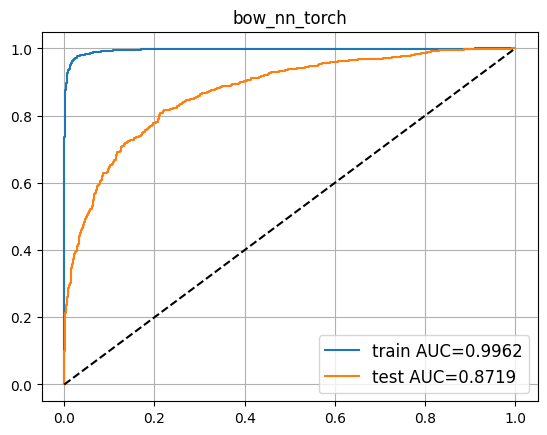

In [9]:
out_dict = visualize_and_save_results(
    bow_nn_model,
    "bow_nn_torch",
    X_train_bow_torch,
    X_test_bow_torch,
    y_train,
    y_test,
    out_dict,
)

assert (
    out_dict["bow_log_reg_sklearn_test"] - out_dict["bow_nn_torch_test"] < 0.01
), "AUC ROC on test data should be close to the sklearn implementation"

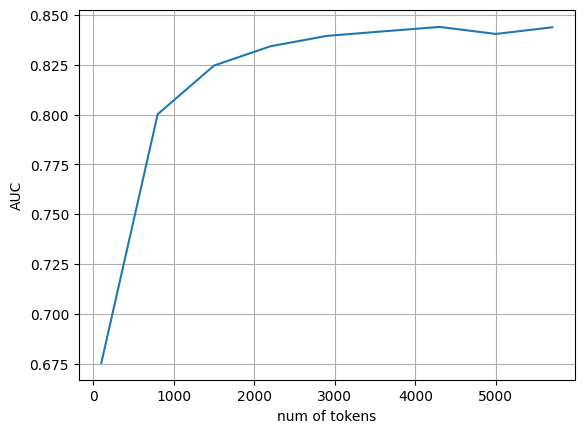

In [10]:
vocab_sizes_list = np.arange(100, 5800, 700)
results = []

class BoWLogisticRegression(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 2)
    def forward(self, x):
        return self.linear(x)

for k in vocab_sizes_list:
    counts_k = Counter(" ".join(texts_train).split())
    bow_vocabulary_k = [token for token, _ in counts_k.most_common(k)]
    
    def text_to_bow_k(text):
        vec = np.zeros(k, dtype=np.float32)
        c = Counter(text.split())
        for i, token in enumerate(bow_vocabulary_k):
            if token in c:
                vec[i] = c[token]
        return vec
    
    X_train_bow_k = np.stack([text_to_bow_k(txt) for txt in texts_train])
    X_test_bow_k = np.stack([text_to_bow_k(txt) for txt in texts_test])
    
    X_train_bow_k_torch = torch.tensor(X_train_bow_k, dtype=torch.float32, device=device)
    X_test_bow_k_torch = torch.tensor(X_test_bow_k, dtype=torch.float32, device=device)
    
    model_k = BoWLogisticRegression(k).to(device)
    loss_function_k = nn.CrossEntropyLoss()
    opt_k = torch.optim.Adam(model_k.parameters(), lr=1e-3)
    
    def train_model_k(
        model,
        opt,
        X_train_torch,
        y_train_torch,
        X_val_torch,
        y_val_torch,
        n_iterations=700,
        batch_size=32,
        show_plots=False,
        eval_every=100
    ):
        tr_loss = []
        for i in range(n_iterations):
            ix = np.random.randint(0, len(X_train_torch), batch_size)
            x_batch = X_train_torch[ix]
            y_batch = y_train_torch[ix]

            y_predicted = model(x_batch)
            loss_ = loss_function_k(y_predicted, y_batch)
            loss_.backward()
            opt.step()
            opt.zero_grad()
            tr_loss.append(loss_.item())
        return model

    model_k = train_model_k(
        model_k,
        opt_k,
        X_train_bow_k_torch,
        y_train_torch,
        X_test_bow_k_torch,
        y_test_torch,
        n_iterations=700
    )

    with torch.no_grad():
        logits_test = model_k(X_test_bow_k_torch)
        probas_test = F.softmax(logits_test, dim=1)[:, 1].cpu().numpy()

    auc = roc_auc_score(y_test, probas_test)
    results.append(auc)

assert len(results) == len(vocab_sizes_list), "Check the code above"
assert min(results) >= 0.65, "Seems like the model is not trained well enough"
assert results[-1] > 0.84, "Best AUC ROC should not be lower than 0.84"

plt.plot(vocab_sizes_list, results)
plt.xlabel("num of tokens")
plt.ylabel("AUC")
plt.grid()

out_dict["bow_k_vary"] = results

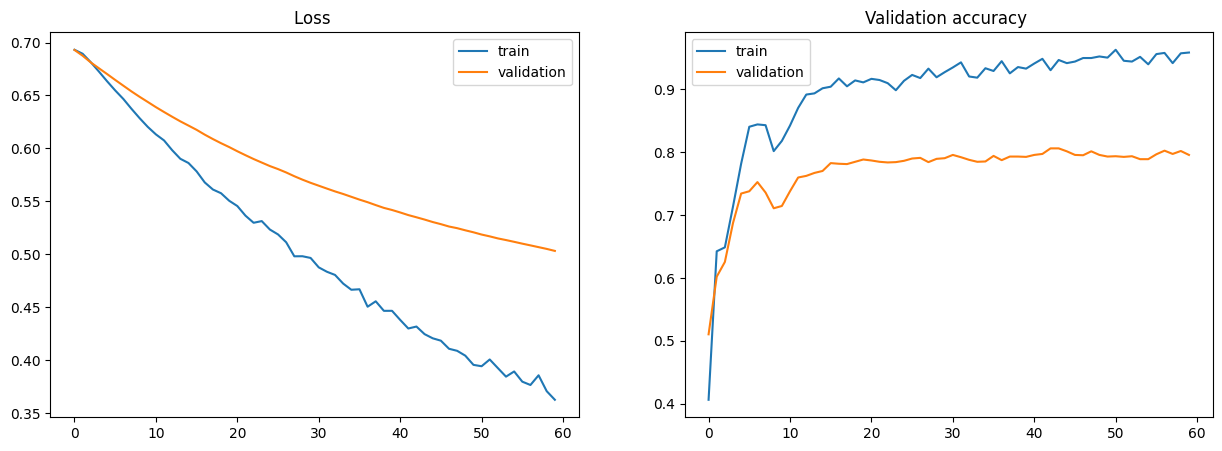

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer_tfidf = TfidfVectorizer(max_features=10000)
X_train_tfidf_sp = vectorizer_tfidf.fit_transform(texts_train)
X_test_tfidf_sp = vectorizer_tfidf.transform(texts_test)

X_train_tfidf = X_train_tfidf_sp.toarray()
X_test_tfidf = X_test_tfidf_sp.toarray()

class TfidfLogisticRegression(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 2)
    def forward(self, x):
        return self.linear(x)

model = TfidfLogisticRegression(X_train_tfidf.shape[1]).to(device)

loss_function = nn.CrossEntropyLoss()
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

X_train_tfidf_torch = torch.tensor(X_train_tfidf, dtype=torch.float32, device=device)
X_test_tfidf_torch = torch.tensor(X_test_tfidf, dtype=torch.float32, device=device)

model_tf_idf = train_model(
    model,
    opt,
    X_train_tfidf_torch,
    y_train_torch,
    X_test_tfidf_torch,
    y_test_torch,
    n_iterations=3000
)

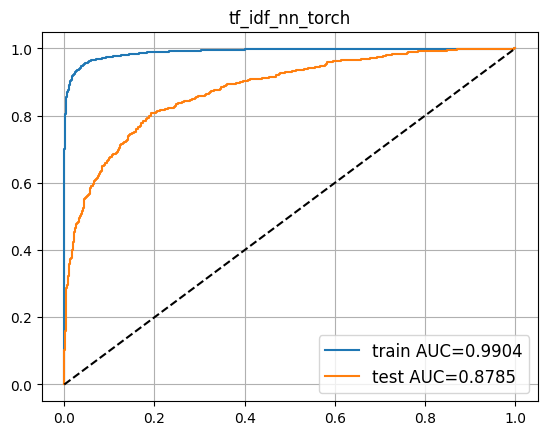

In [12]:
out_dict = visualize_and_save_results(
    model_tf_idf,
    "tf_idf_nn_torch",
    X_train_tfidf_torch,
    X_test_tfidf_torch,
    y_train,
    y_test,
    out_dict,
)

assert (
    out_dict["tf_idf_nn_torch_test"] >= out_dict["bow_nn_torch_test"]
), "AUC ROC on test data should be better or close to BoW for TF-iDF features"
# __________end of block__________

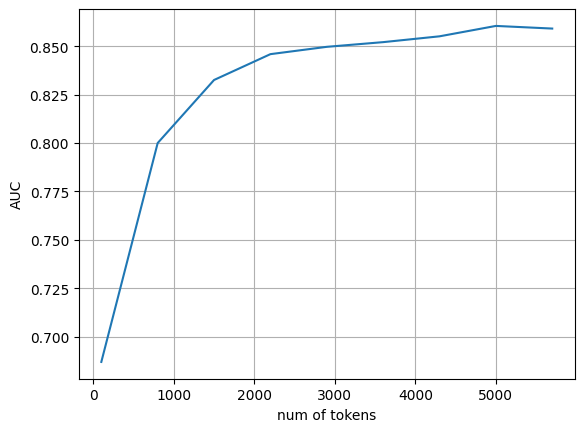

In [13]:
vocab_sizes_list = np.arange(100, 5800, 700)
results = []

for k in vocab_sizes_list:
    vect_k = TfidfVectorizer(max_features=k)
    X_train_tfidf_k_sp = vect_k.fit_transform(texts_train)
    X_test_tfidf_k_sp = vect_k.transform(texts_test)
    
    X_train_tfidf_k = X_train_tfidf_k_sp.toarray()
    X_test_tfidf_k = X_test_tfidf_k_sp.toarray()
    
    X_train_tfidf_k_torch = torch.tensor(X_train_tfidf_k, dtype=torch.float32, device=device)
    X_test_tfidf_k_torch = torch.tensor(X_test_tfidf_k, dtype=torch.float32, device=device)
    
    model_k = nn.Linear(k, 2).to(device)
    loss_function_k = nn.CrossEntropyLoss()
    optimizer_k = torch.optim.Adam(model_k.parameters(), lr=1e-3)
    
    def train_tfidf_k(model, optimizer, X_train_t, y_train_t, X_val_t, y_val_t, n_iter=700, batch_size=32):
        for i in range(n_iter):
            ix = np.random.randint(0, len(X_train_t), batch_size)
            x_batch = X_train_t[ix]
            y_batch = y_train_t[ix]
            logits_ = model(x_batch)
            loss_ = loss_function_k(logits_, y_batch)
            loss_.backward()
            optimizer.step()
            optimizer.zero_grad()
        return model

    model_k = train_tfidf_k(model_k, optimizer_k, X_train_tfidf_k_torch, y_train_torch,
                            X_test_tfidf_k_torch, y_test_torch, n_iter=700)

    with torch.no_grad():
        logits_test = model_k(X_test_tfidf_k_torch)
        prob_test = F.softmax(logits_test, dim=1)[:, 1].cpu().numpy()
    
    auc_val = roc_auc_score(y_test, prob_test)
    results.append(auc_val)

assert len(results) == len(vocab_sizes_list), "Check the code above"
assert min(results) >= 0.65, "Seems like the model is not trained well enough"
assert results[-1] > 0.85, "Best AUC ROC for TF-iDF should not be lower than 0.84"

plt.plot(vocab_sizes_list, results)
plt.xlabel("num of tokens")
plt.ylabel("AUC")
plt.grid()

out_dict["tf_idf_k_vary"] = results

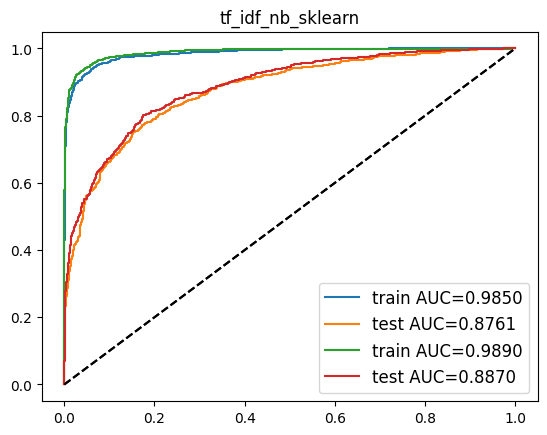

In [14]:
from sklearn.naive_bayes import MultinomialNB

clf_nb_bow = MultinomialNB().fit(X_train_bow, y_train)

out_dict = visualize_and_save_results(
    clf_nb_bow, 'bow_nb_sklearn', X_train_bow, X_test_bow, y_train, y_test, out_dict
)

clf_nb_tfidf = MultinomialNB().fit(X_train_tfidf, y_train)

out_dict = visualize_and_save_results(
    clf_nb_tfidf, 'tf_idf_nb_sklearn', X_train_tfidf, X_test_tfidf, y_train, y_test, out_dict
)

assert (
    out_dict["tf_idf_nb_sklearn_test"] > out_dict["bow_nb_sklearn_test"]
), " TF-iDF results should be better"
assert (
    out_dict["tf_idf_nb_sklearn_test"] > 0.86
), "TF-iDF Naive Bayes score should be above 0.86"

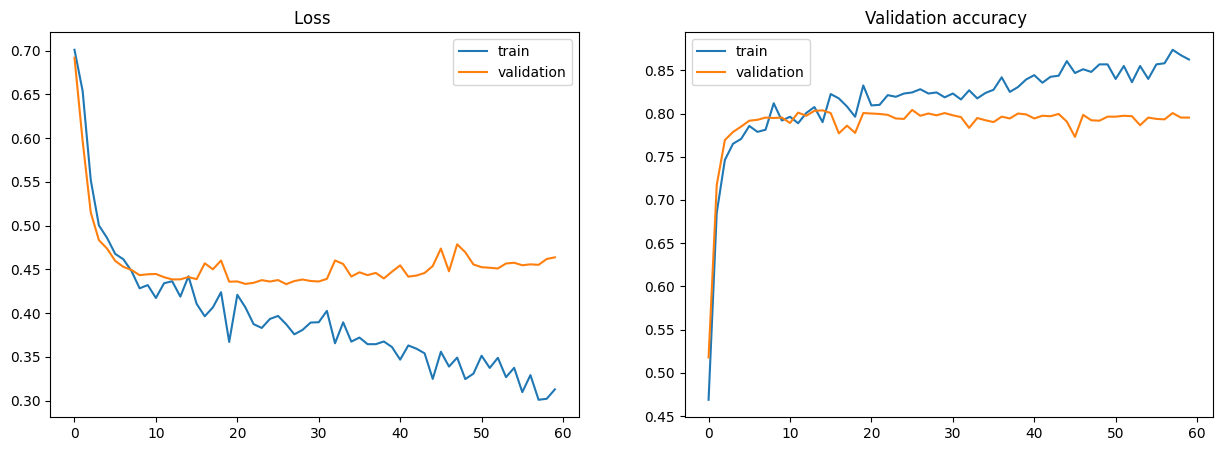

In [15]:
import gensim.downloader as api

gensim_embedding_model = api.load("glove-wiki-gigaword-300")

def text_to_average_embedding(text, gensim_embedding_model):
    tokens = text.split()
    embeddings = []
    for t in tokens:
        if t in gensim_embedding_model:
            embeddings.append(gensim_embedding_model[t])
    if len(embeddings) == 0:
        # если вдруг в тексте ни одного слова из словаря нет, вернем нули
        return np.zeros(gensim_embedding_model.vector_size, dtype=np.float32)
    else:
        return np.mean(embeddings, axis=0).astype(np.float32)

X_train_emb = [text_to_average_embedding(text, gensim_embedding_model) for text in texts_train]
X_test_emb = [text_to_average_embedding(text, gensim_embedding_model) for text in texts_test]

assert len(X_train_emb[0]) == gensim_embedding_model.vector_size, "Seems like the embedding shape is wrong"

X_train_emb_torch = torch.tensor(X_train_emb, dtype=torch.float32, device=device)
X_test_emb_torch = torch.tensor(X_test_emb, dtype=torch.float32, device=device)

y_train_torch = torch.tensor(y_train, dtype=torch.long, device=device)
y_test_torch = torch.tensor(y_test, dtype=torch.long, device=device)

class EmbNNModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 2)
        )
    def forward(self, x):
        return self.net(x)

model = EmbNNModel(gensim_embedding_model.vector_size, hidden_dim=64).to(device)
loss_function = nn.CrossEntropyLoss()
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

model = train_model(model, opt, X_train_emb_torch, y_train_torch, X_test_emb_torch, y_test_torch, n_iterations=3000)

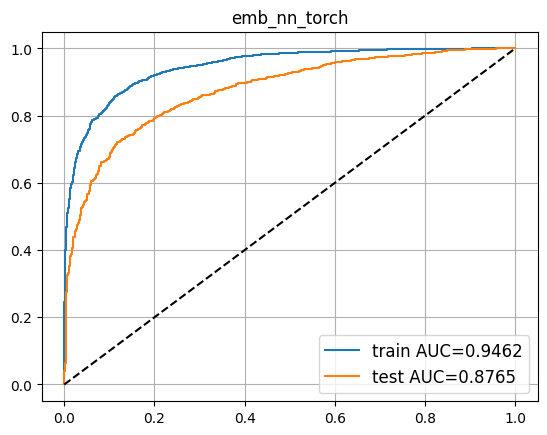

In [16]:
out_dict = visualize_and_save_results(
    model,
    "emb_nn_torch",
    X_train_emb_torch,
    X_test_emb_torch,
    y_train,
    y_test,
    out_dict,
)
assert (
    out_dict["emb_nn_torch_test"] > 0.87
), "AUC ROC on test data should be better than 0.86"
assert (
    out_dict["emb_nn_torch_train"] - out_dict["emb_nn_torch_test"] < 0.1
), "AUC ROC on test and train data should not be different more than by 0.1"

In [17]:
FILENAME = "submission_dict_hw_text_classification.json"
with open(FILENAME, "w") as iofile:
    json.dump(out_dict, iofile)
print(f"File saved to `{FILENAME}`")

File saved to `submission_dict_hw_text_classification.json`
